<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Juan Manuel Velásquez Castañeda - 1037856273

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### **Solución 1:**

###🍷 Dataset: Wine Recognition (Reconocimiento de Vinos)
Este conjunto de datos contiene los resultados de un análisis químico de vinos cultivados en la misma región de Italia, pero derivados de tres cultivares (tipos de uva) diferentes.
* **alcohol:** Grado de alcohol del vino.
* **malic_acid:** Ácido málico (aporta acidez).
* **ash:** Nivel de cenizas tras la evaporación e incineración.
* **alcalinity_of_ash:** Alcalinidad de las cenizas.
* **magnesium:** Nivel de magnesio.
* **total_phenols:** Fenoles totales.
* **flavanoids:** Flavonoides (antioxidantes).
* **nonflavanoid_phenols:** Fenoles no flavonoides.
* **proanthocyanins:** Proantocianidinas.
* **color_intensity:** Intensidad del color del vino.
* **hue:** Matiz del vino.
* **od280/od315_of_diluted_wines:** Medición de la dilución de proteínas en el vino.
* **proline:** Nivel del aminoácido prolina.

**1. Carga el conjunto de datos:**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import zscore

wine = load_wine()

**2. Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles:**

In [7]:
df = pd.DataFrame(wine["data"], columns=wine.feature_names)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


**3. Selecciona al menos tres variables numéricas para el análisis:**

**Caracteristicas seleccionadas:**
* `alcohol`
* `alcalinity_of_ash`
* `nonflavanoid_phenols`

**4. Aplica los métodos de escalamiento:**

In [8]:
# Selección de variables
caracteristicas = ['alcohol', 'alcalinity_of_ash', 'nonflavanoid_phenols']
df_sel = df[caracteristicas].copy()

#StandardScaler
scaler_std = StandardScaler()
df_std = pd.DataFrame(scaler_std.fit_transform(df_sel), columns=caracteristicas)

#MinMaxScaler
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_sel), columns=caracteristicas)

#RobustScaler
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(scaler_robust.fit_transform(df_sel), columns=caracteristicas)

#Z-Score (Cálculo manual para diferenciarlo del uso de StandardScaler en código)
df_zscore = pd.DataFrame(zscore(df_sel, axis=0), columns=caracteristicas)

**5. Gráficas:**

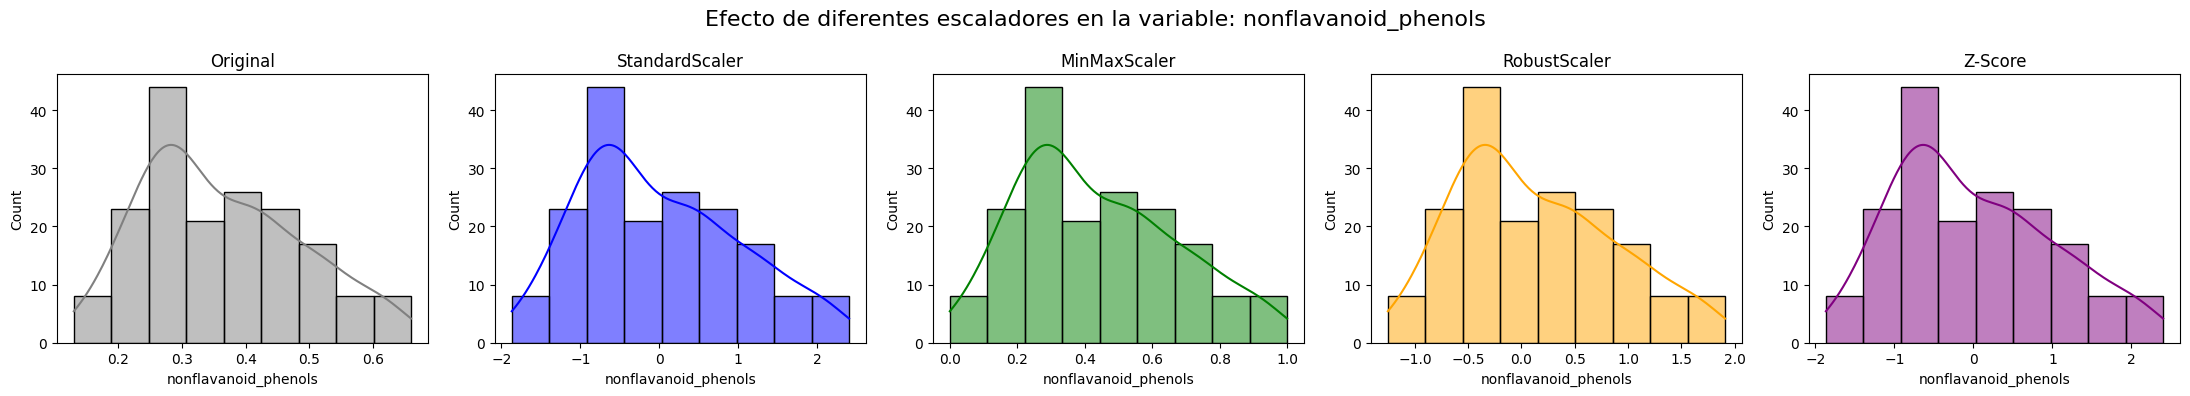

In [9]:
variable_a_graficar = 'nonflavanoid_phenols'

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
fig.suptitle(f'Efecto de diferentes escaladores en la variable: {variable_a_graficar}', fontsize=16)

#confi visual para cada subgráfico
sns.histplot(df_sel[variable_a_graficar], kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original')
sns.histplot(df_std[variable_a_graficar], kde=True, ax=axes[1], color='blue')
axes[1].set_title('StandardScaler')
sns.histplot(df_minmax[variable_a_graficar], kde=True, ax=axes[2], color='green')
axes[2].set_title('MinMaxScaler')
sns.histplot(df_robust[variable_a_graficar], kde=True, ax=axes[3], color='orange')
axes[3].set_title('RobustScaler')
sns.histplot(df_zscore[variable_a_graficar], kde=True, ax=axes[4], color='purple')
axes[4].set_title('Z-Score')

plt.tight_layout()
plt.show()

**6. Análisis**

Entonces, los metodos para escalar lo que me hacen es ajustar la magnitud de los datos (en mi eje x) sin llegar a alterar la distribución original. Resumidamente, el `MinMaxScaler` lo que me hace es comprimir los datos entre 0 y 1, el `StandardScale` y el `Z-score` matematicamente me hacen lo mismo, restar la media y dividir por la desviación estándar, por eso las graficas son iguales. Y el `RobustScaler` que como usted profe lo dijo en clase maneja la mediana y los rangos intercuartilicos, entonces me maneja los outlayers. Dado que no noto estos outlaiers extremos elijo **StandarsScaler** buscando normalidad (les da una varianza de 1).

---

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### **Solución 2:**

###🩸 Dataset: Diabetes (Versión Escalada y Versión Original)
*Nota: El bloque 2 y 4 corresponden al mismo dataset, pero el bloque 2 contiene los datos pre-escalados (centrados en cero por defecto en `sklearn`), mientras que el bloque 4 contiene los valores médicos reales.*
* **age:** Edad del paciente en años.
* **sex:** Sexo del paciente.
* **bmi:** Índice de Masa Corporal (Body Mass Index).
* **bp:** Presión arterial media (Blood Pressure).
* **s1 (tc):** Colesterol total en sangre.
* **s2 (ldl):** Lipoproteínas de baja densidad (Colesterol "malo").
* **s3 (hdl):** Lipoproteínas de alta densidad (Colesterol "bueno").
* **s4 (tch):** Hormona estimulante del tiroides.
* **s5 (ltg):** Lamotrigina (Posiblemente niveles de triglicéridos/logaritmo de triglicéridos en suero).
* **s6 (glu):** Nivel de azúcar en la sangre.

**1. Carga el conjunto de datos:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import zscore

diabetes = load_diabetes()

**2. Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles:**

In [ ]:
df = pd.DataFrame(diabetes["data"], columns=diabetes.feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


**3. Selecciona al menos tres variables numéricas para el análisis:**

**Caracteristicas seleccionadas:**

* `bmi`
* `s1`
* `s5`

**4. Aplica los métodos de escalamiento sobre las variables seleccionadas:**

In [ ]:
# Selección de variables
caracteristicas = ["age", 'bmi', 's1', "s2", "s3", "s4", 's5', "s6", "bp"]

df_sel = df[caracteristicas].copy()


# RobustScaler
scaler_robust = RobustScaler()
df_robust = pd.DataFrame(scaler_robust.fit_transform(df_sel), columns=caracteristicas)

# Z-Score
df_zscore = pd.DataFrame(zscore(df_sel, axis=0), columns=caracteristicas)

**5. Gráficas:**

Text(0.5, 1.0, 'RobustScaler')

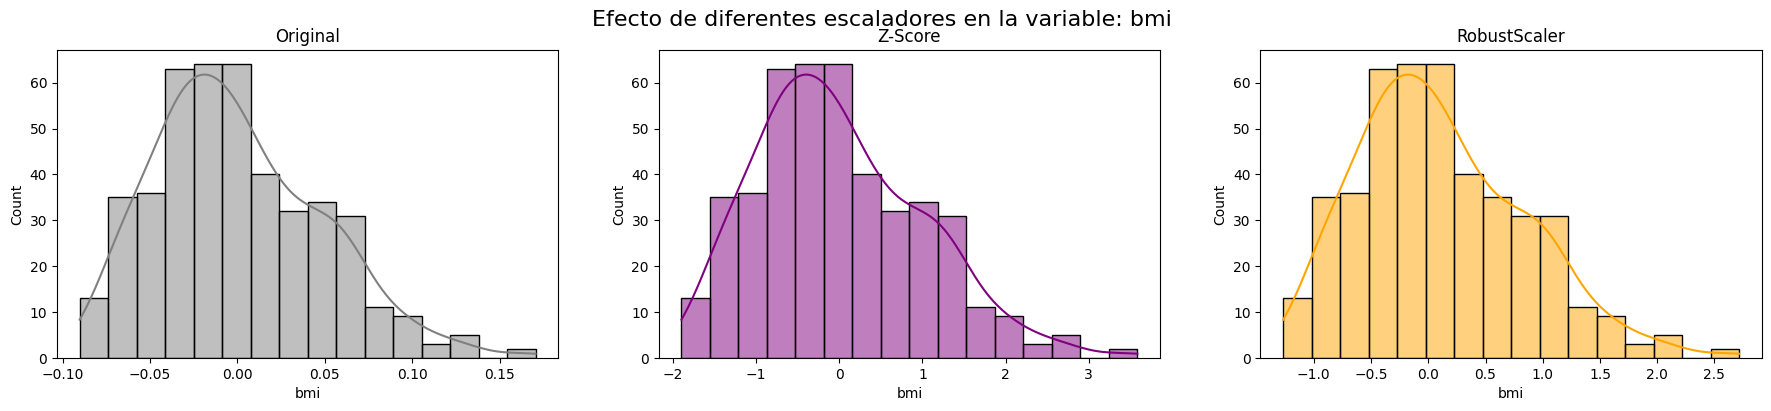

In [ ]:
variable_a_graficar = 'bmi'

fig, axes = plt.subplots(1, 3, figsize=(22, 4))
fig.suptitle(f'Efecto de diferentes escaladores en la variable: {variable_a_graficar}', fontsize=16)

# Configuración visual para cada subgráfico
sns.histplot(df_sel[variable_a_graficar], kde=True, ax=axes[0], color='gray')
axes[0].set_title('Original')
sns.histplot(df_zscore[variable_a_graficar], kde=True, ax=axes[1], color='purple')
axes[1].set_title('Z-Score')
sns.histplot(df_robust[variable_a_graficar], kde=True, ax=axes[2], color='orange')
axes[2].set_title('RobustScaler')

**6. Análisis:**
Como lo exprese anteriormente Z-Score ajusta los datos usando la media y la desviación estándar, haciéndola algo vulnerable a distorsiones si existen valores atípicos. Lo que hace RobustScaler es centra los datos usando la mediana y el rango intercuartílico, quitando la influencia de outlaiers. Metiendome un poco en contexto con el conjuntos de datos médicos como este, donde pueden existir pacientes con métricas anormales outliers, **RobustScaler** para mi seria el método más confiable, ya que estandariza correctamente a la mayoría de la población sin que los casos excepcionales rompan la escala por decirlo asi.

---

## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### **Solución 3:**

###🏡 Dataset: California Housing (Viviendas en California)
Datos recopilados del censo de EE.UU. de 1990 para predecir el valor medio de las casas en distritos de California.
* **MedInc:** Ingreso medio de los hogares en el distrito (en decenas de miles de dólares).
* **HouseAge:** Edad mediana de las casas en el distrito.
* **AveRooms:** Número promedio de habitaciones por hogar.
* **AveBedrms:** Número promedio de dormitorios por hogar.
* **Population:** Población total del bloque/distrito.
* **AveOccup:** Promedio de ocupantes por hogar.
* **Latitude:** Coordenada de latitud del bloque.
* **Longitude:** Coordenada de longitud del bloque.

**1. Carga el conjunto de datos:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Normalizer
from sklearn.datasets import fetch_california_housing

california_housing = fetch_california_housing()

**2. Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles:**

In [ ]:
df = pd.DataFrame(california_housing["data"], columns=california_housing.feature_names)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**3. Selecciona al menos tres variables numéricas para el análisis:**

**Caracteristicas seleccionadas:**

* `AveRooms`
* `AveBedrms`
* `Population`

**4. plica los métodos de normalización sobre las variables seleccionadas:**

In [ ]:
caracteristicas = ['AveRooms', 'AveBedrms', 'Population']

#escalamos primero
scaler = MinMaxScaler()
df_escalado = pd.DataFrame(scaler.fit_transform(df_sel), columns=caracteristicas)

df_sel = df_escalado[caracteristicas].copy()

# Normalización L1 (la suma de los valores absolutos de la fila será 1)
norm_l1 = Normalizer(norm='l1')
df_l1 = pd.DataFrame(norm_l1.fit_transform(df_sel), columns=caracteristicas)

# Normalización L2 (la suma de los cuadrados de la fila será 1)
norm_l2 = Normalizer(norm='l2')
df_l2 = pd.DataFrame(norm_l2.fit_transform(df_sel), columns=caracteristicas)

**5. Gráficas:**

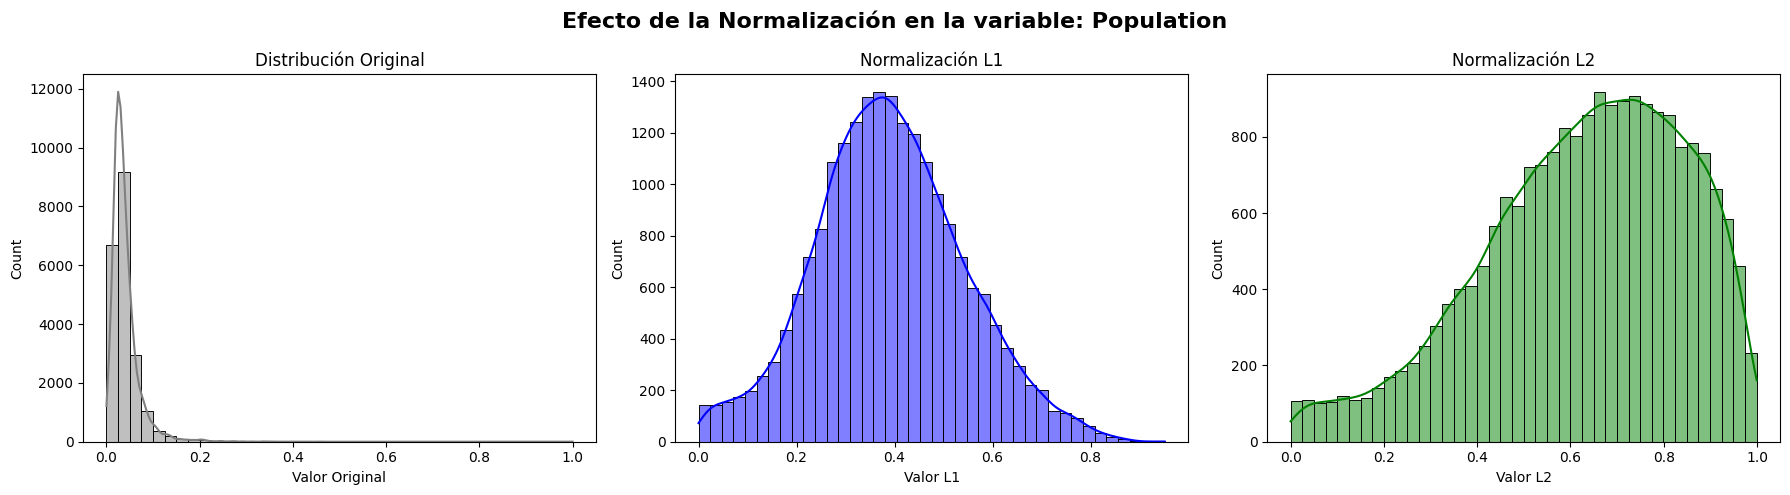

In [ ]:
variable_a_graficar = 'Population'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Efecto de la Normalización en la variable: {variable_a_graficar}', fontsize=16, fontweight='bold')

# Distribución Original
sns.histplot(df_sel[variable_a_graficar], kde=True, ax=axes[0], color='gray', bins=40)
axes[0].set_title('Distribución Original')
axes[0].set_xlabel('Valor Original')

# Normalización L1
sns.histplot(df_l1[variable_a_graficar], kde=True, ax=axes[1], color='blue', bins=40)
axes[1].set_title('Normalización L1')
axes[1].set_xlabel('Valor L1')

# Normalización L2
sns.histplot(df_l2[variable_a_graficar], kde=True, ax=axes[2], color='green', bins=40)
axes[2].set_title('Normalización L2')
axes[2].set_xlabel('Valor L2')

plt.tight_layout()
plt.show()

**6. Análisis:**

En comparación con el escalamiento, la normalización ajusta los valores por fila (muestras) para que su magnitud sea igual a 1. La normalización L1 (suma absoluta) es útil para entender los datos a manera de una proporción o una probabilidad, mientras que la normalización L2 (distancia euclidiana) (investigando profe) penaliza menos los valores pequeños y es ideal para algoritmos espaciales. Despues de escalar con minmax los datos para evitar que variables grandes dominen, para mi la normalización **L1** seria la mas recomendable en este caso, me entrega una distribución muy semejante a la normal en comparación a L2 que me entrega un sesgo a izquierda, quiero mas simetria.


## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### **Solución 4:**

###🩸 Dataset: Diabetes (Versión Escalada y Versión Original)
*Nota: El bloque 2 y 4 corresponden al mismo dataset, pero el bloque 2 contiene los datos pre-escalados (centrados en cero por defecto en `sklearn`), mientras que el bloque 4 contiene los valores médicos reales.*
* **age:** Edad del paciente en años.
* **sex:** Sexo del paciente.
* **bmi:** Índice de Masa Corporal (Body Mass Index).
* **bp:** Presión arterial media (Blood Pressure).
* **s1 (tc):** Colesterol total en sangre.
* **s2 (ldl):** Lipoproteínas de baja densidad (Colesterol "malo").
* **s3 (hdl):** Lipoproteínas de alta densidad (Colesterol "bueno").
* **s4 (tch):** Hormona estimulante del tiroides.
* **s5 (ltg):** Lamotrigina (Posiblemente niveles de triglicéridos/logaritmo de triglicéridos en suero).
* **s6 (glu):** Nivel de azúcar en la sangre.

**1. Carga el conjunto de datos:**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(scaled=False)

**2. Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles:**

In [14]:
df = pd.DataFrame(diabetes["data"], columns=diabetes.feature_names)

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0


**3. Selecciona al menos dos variables numéricas para el análisis**

**Caracteristicas seleccionadas:**

* `bmi`
* `s5`


**4. Aplica las transformaciones sobre una de las variables seleccionadas:**

In [15]:
caracteristicas = ['bmi', 's5']

df_sel = df[caracteristicas].copy()

# usamos bmi
var = 'bmi'
x = df_sel[var]

# Transformación logarítmica
df_sel['log'] = np.log(x)

# Transformación logarítmica reflejada (k - x, donde k = max(x) + 1)
k = x.max() + 1
df_sel['log_reflejado'] = np.log(k - x)

# Transformación cuadrática
df_sel['cuadratica'] = x ** 2

# Transformación Box-Cox
df_sel['boxcox'], lambda_optima = boxcox(x)

**5. Gráficas:**

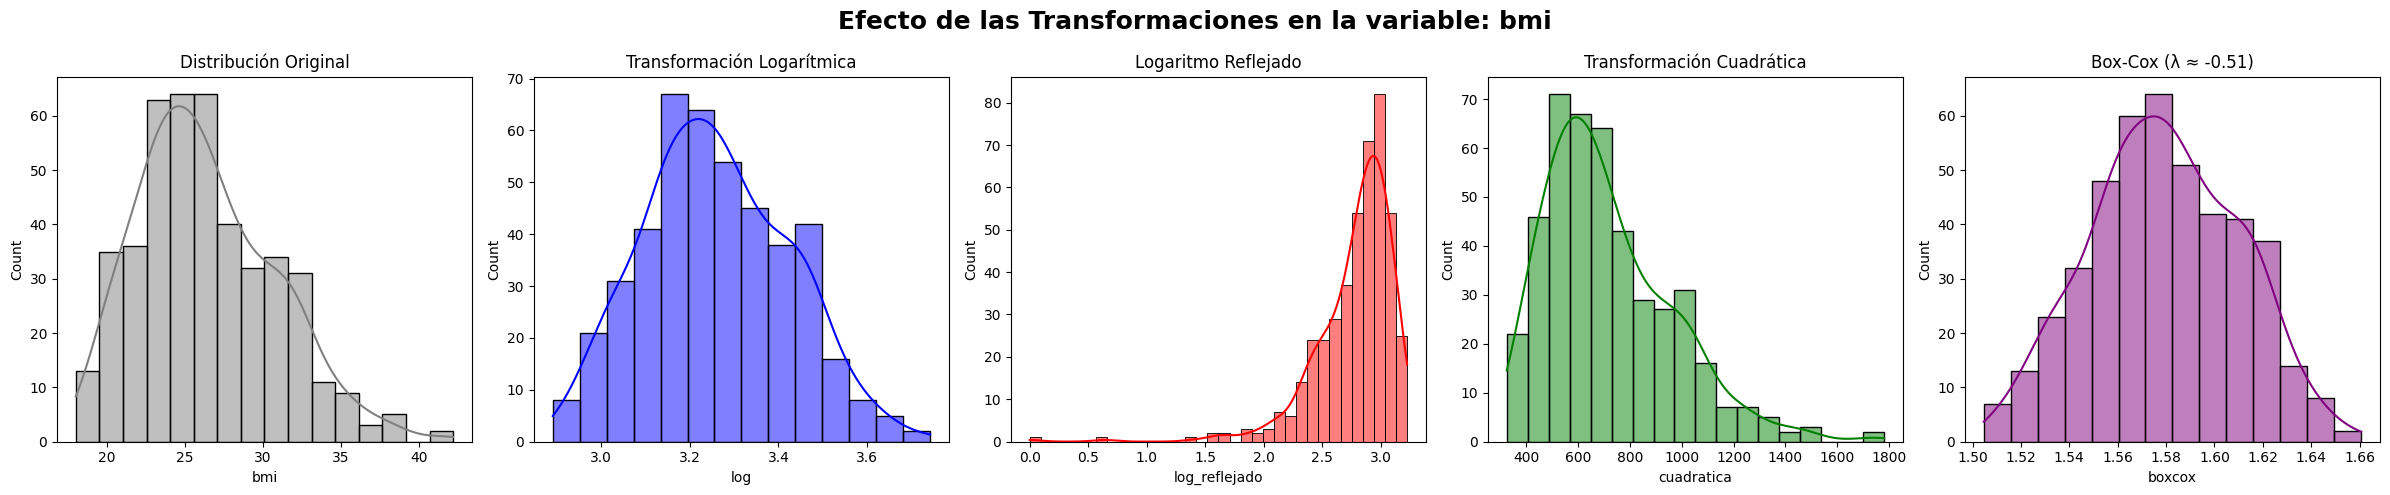

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle(f'Efecto de las Transformaciones en la variable: {var}', fontsize=18, fontweight='bold')

#configuración de los 5 escenarios
sns.histplot(x, kde=True, ax=axes[0], color='gray')
axes[0].set_title('Distribución Original')

sns.histplot(df_sel['log'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Transformación Logarítmica')

sns.histplot(df_sel['log_reflejado'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Logaritmo Reflejado')

sns.histplot(df_sel['cuadratica'], kde=True, ax=axes[3], color='green')
axes[3].set_title('Transformación Cuadrática')

sns.histplot(df_sel['boxcox'], kde=True, ax=axes[4], color='purple')
axes[4].set_title(f'Box-Cox (λ ≈ {lambda_optima:.2f})')

plt.tight_layout()
plt.show()

**6. Análisis:**

La `transformación logarítmica` mejoró parcialmente la distribución al comprimir la cola **derecha**, por otro lado el `logaritmo reflejado` resultó contraproducente al incluir asimetría negativa, dado que esta técnica está diseñada para colas **izquierdas**. Creo que la `transformación cuadrática` fue la menos adecuada, porque me amplifica los outlaires y me empeora la asimetría original. La transformación `Box-Cox (λ ≈ −0.51)` produjo la distribución más cercana a la normalidad al encontrar automáticamente el exponente óptimo, siendo mas efectiva que log simple. Por tanto, para mi Box-Cox es la técnica más recomendable en este caso.

---

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **Heart Disease** desde la librería `seaborn` usando `load_dataset("heart")`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

### **Solución 5:**

❤️ Dataset: Heart Disease (Enfermedades Cardíacas)
Datos clínicos de pacientes utilizados para predecir la presencia o ausencia de enfermedades cardíacas.
* **age:** Edad en años.
* **sex:** Sexo (1 = Hombre; 0 = Mujer).
* **cp:** Tipo de dolor en el pecho (Chest Pain Type).
* **trestbps:** Presión arterial en reposo (en mm Hg al ingresar al hospital).
* **chol:** Colesterol en suero (en mg/dl).
* **fbs:** Nivel de azúcar en sangre en ayunas > 120 mg/dl (1 = Verdadero; 0 = Falso).
* **restecg:** Resultados del electrocardiograma en reposo.
* **thalach:** Frecuencia cardíaca máxima alcanzada durante la prueba de esfuerzo.
* **exang:** Angina inducida por el ejercicio (1 = Sí; 0 = No).
* **oldpeak:** Depresión del segmento ST inducida por el ejercicio en relación con el reposo.
* **slope:** La pendiente del segmento ST en el pico del ejercicio.
* **ca:** Número de vasos sanguíneos principales (0-3) coloreados por fluoroscopia.
* **thal:** Resultados de la prueba de esfuerzo con talio (3 = Normal; 6 = Defecto fijo; 7 = Defecto reversible).

**1. Carga el conjunto de datos:**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

#cargar el conjunto de datos desde ucimlrepo
heart_disease = fetch_ucirepo(id=45)

**2. Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles:**

In [18]:
df = heart_disease.data.features

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


**3. Selecciona al menos dos variables numéricas para el análisis:**

**Caracteristicas seleccionadas:**

* `chol`
* `trestbps`


**4. Aplica las transformaciones sobre una de las variables seleccionadas:**

In [28]:
#Es importante eliminar los NaN para que las matemáticas no fallen
caracteristicas = ['chol', 'trestbps','thalach']
df_sel = df[caracteristicas].dropna().copy()

# 4. Aplicación de transformaciones en thalach
var = 'thalach'
x = df_sel[var]

# a) Raíz cuadrada
df_sel['raiz_cuadrada'] = np.sqrt(x)

# b) Recíproca
df_sel['reciproca'] = 1 / x

# c) Yeo-Johnson (Requiere formato 2D, por eso usamos [[var]])
pt = PowerTransformer(method="yeo-johnson")
df_sel['yeo_johnson'] = pt.fit_transform(df_sel[[var]])

**5. Gráficas:**

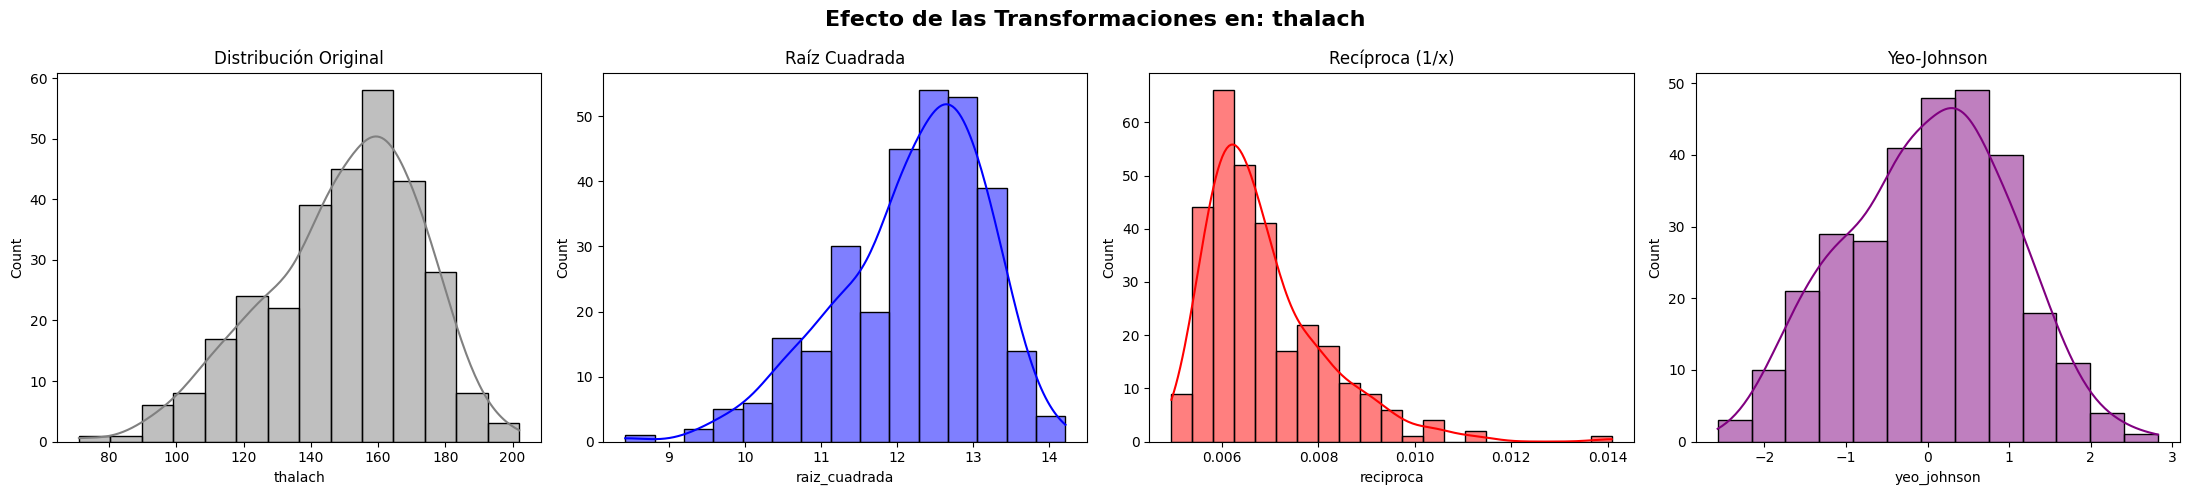

In [30]:
# 5. Generación de gráficas comparativas
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(f'Efecto de las Transformaciones en: {var}', fontsize=16, fontweight='bold')

# Original
sns.histplot(x, kde=True, ax=axes[0], color='gray')
axes[0].set_title('Distribución Original')

# Raíz Cuadrada
sns.histplot(df_sel['raiz_cuadrada'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('Raíz Cuadrada')

# Recíproca
sns.histplot(df_sel['reciproca'], kde=True, ax=axes[2], color='red')
axes[2].set_title('Recíproca (1/x)')

# Yeo-Johnson
sns.histplot(df_sel['yeo_johnson'], kde=True, ax=axes[3], color='purple')
axes[3].set_title('Yeo-Johnson')

plt.tight_layout()
plt.show()

**6. Análisis:**

Se aplican las transformaciones sobre thalach, que presenta asimetría negativa con un poco decola a izquierda. La `raíz cuadrada` mejoró alguito la distribución al suavizar la asimetría, pero no logra una simetría completa porque es una técnica pensada principalmente para colas derechas. La `transformación recíproca` creo que seria la peor opción, al invertir la escala convirtió la asimetría negativa en positiva, distorsionando todo. La `transformación Yeo-Johnson` produjo la distribución más simétrica por su capacidad de manejar tanto asimetrías positivas como negativas mediante un λ óptimo calculado automáticamente. Por lo tanto, para mi `Yeo-Johnson` es la técnica más recomendable para thalach.